# From scratch: gradient boosting as residual fitting

Implements the gradient boosting loop by hand for squared-error loss, where — as derived in
`notes.md`'s Mathematical foundation — the pseudo-residual reduces to the ordinary residual
$r_i = y_i - F(x_i)$. Each round fits a shallow `sklearn.tree.DecisionTreeRegressor` to the current
residuals and adds a shrunk copy of it to the running ensemble prediction $F(x)$. No
`sklearn.ensemble.GradientBoostingRegressor` is used here — that's the Practical implementation
step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor

%matplotlib inline
rng = np.random.RandomState(0)

## 1) Toy 1D regression problem

A noisy, non-linear target function $y = x \sin(x) + \varepsilon$ — something a single shallow
tree can only approximate crudely, giving successive rounds real residual structure to fit.

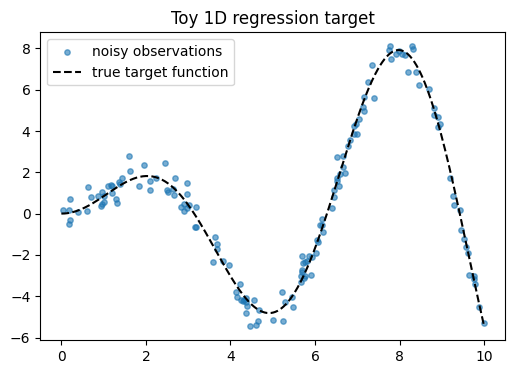

In [2]:
X = np.sort(rng.uniform(0, 10, size=150)).reshape(-1, 1)
y_true_fn = lambda x: x.ravel() * np.sin(x.ravel())
y = y_true_fn(X) + rng.normal(scale=0.5, size=len(X))

X_grid = np.linspace(0, 10, 400).reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, s=15, alpha=0.6, label="noisy observations")
plt.plot(X_grid, y_true_fn(X_grid), color="black", linestyle="--", label="true target function")
plt.legend(); plt.title("Toy 1D regression target")
plt.show()

## 2) The manual gradient boosting loop

1. $F_0(x) = \bar{y}$ (mean of targets — the argmin of squared-error loss over a constant).
2. For each round $t$: compute residuals $r_i = y_i - F_{t-1}(x_i)$ (the negative gradient of
   $\frac12(y_i - F)^2$ w.r.t. $F$ — see `notes.md`), fit a shallow `DecisionTreeRegressor` to
   $(x_i, r_i)$, then update $F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$ with shrinkage $\eta$.

In [3]:
def gb_fit(X, y, n_rounds, learning_rate, max_depth=2, rng=None):
    F0 = np.mean(y)
    trees = []
    current_pred = np.full(len(y), F0)
    train_mse = []
    snapshots = {}  # round -> predictions on X_grid, for plotting convergence

    grid_pred = np.full(len(X_grid), F0)

    for t in range(1, n_rounds + 1):
        residuals = y - current_pred                       # pseudo-residuals (= ordinary residuals for MSE)
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
        tree.fit(X, residuals)

        current_pred = current_pred + learning_rate * tree.predict(X)
        grid_pred = grid_pred + learning_rate * tree.predict(X_grid)

        trees.append(tree)
        train_mse.append(np.mean((y - current_pred) ** 2))

        if t in (1, 5, 20, 100):
            snapshots[t] = grid_pred.copy()

    return F0, trees, np.array(train_mse), snapshots


n_rounds = 100
learning_rate = 0.3
F0, trees, train_mse, snapshots = gb_fit(X, y, n_rounds, learning_rate, max_depth=2)
print(f"Training MSE after 1 round:   {train_mse[0]:.4f}")
print(f"Training MSE after 100 rounds: {train_mse[-1]:.4f}")

Training MSE after 1 round:   7.3940
Training MSE after 100 rounds: 0.0469


## 3) Ensemble predictions converging to the target function

Plotting $F_t(x)$ on the grid at several checkpoints (round 1, 5, 20, 100) against the true target
function shows the ensemble sequentially closing the gap — each new shallow tree fits what's left
over from the previous rounds.

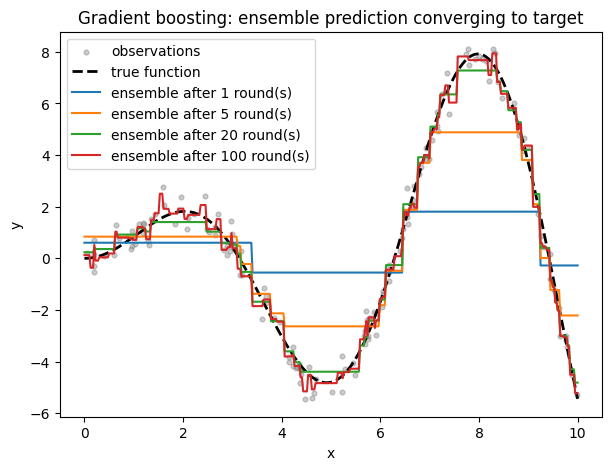

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, s=12, alpha=0.4, color="gray", label="observations")
plt.plot(X_grid, y_true_fn(X_grid), color="black", linestyle="--", linewidth=2, label="true function")
for t, pred in snapshots.items():
    plt.plot(X_grid, pred, label=f"ensemble after {t} round(s)")
plt.legend()
plt.title("Gradient boosting: ensemble prediction converging to target")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

## 4) Training loss vs. round

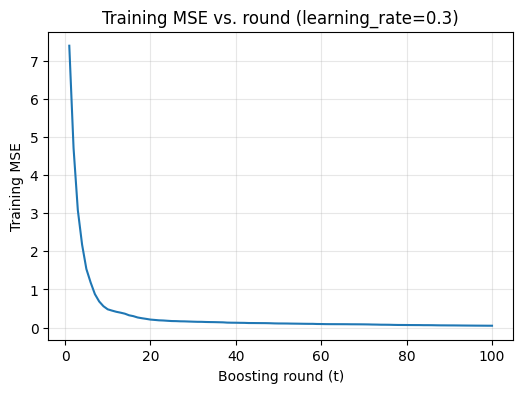

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, n_rounds + 1), train_mse)
plt.xlabel("Boosting round (t)")
plt.ylabel("Training MSE")
plt.title(f"Training MSE vs. round (learning_rate={learning_rate})")
plt.grid(alpha=0.3)
plt.show()

## 5) Effect of learning rate on convergence speed vs. overfitting

Refit with several learning rates, using a held-out validation split this time, to see the
shrinkage tradeoff directly: a larger learning rate should reduce training error fastest per round,
but risks the validation error turning back up (overfitting) sooner than a smaller learning rate.

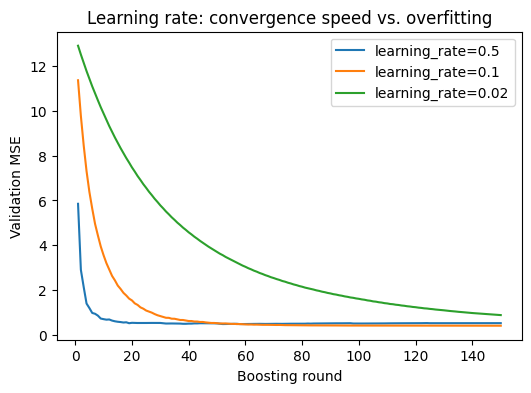

lr=0.5: best val MSE = 0.4894 at round 58, final (round 150) val MSE = 0.5319
lr=0.1: best val MSE = 0.4168 at round 139, final (round 150) val MSE = 0.4170
lr=0.02: best val MSE = 0.8909 at round 150, final (round 150) val MSE = 0.8909


In [6]:
from sklearn.model_selection import train_test_split

Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.3, random_state=7)

def gb_fit_track_val(Xtr, ytr, Xval, yval, n_rounds, learning_rate, max_depth=2):
    F0 = np.mean(ytr)
    train_pred = np.full(len(ytr), F0)
    val_pred = np.full(len(yval), F0)
    val_mse = []
    for t in range(n_rounds):
        residuals = ytr - train_pred
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=0)
        tree.fit(Xtr, residuals)
        train_pred = train_pred + learning_rate * tree.predict(Xtr)
        val_pred = val_pred + learning_rate * tree.predict(Xval)
        val_mse.append(np.mean((yval - val_pred) ** 2))
    return np.array(val_mse)

n_rounds_lr = 150
lrs = [0.5, 0.1, 0.02]
val_curves = {lr: gb_fit_track_val(Xtr, ytr, Xval, yval, n_rounds_lr, lr) for lr in lrs}

plt.figure(figsize=(6, 4))
for lr, curve in val_curves.items():
    plt.plot(range(1, n_rounds_lr + 1), curve, label=f"learning_rate={lr}")
plt.xlabel("Boosting round"); plt.ylabel("Validation MSE")
plt.title("Learning rate: convergence speed vs. overfitting")
plt.legend()
plt.show()

for lr, curve in val_curves.items():
    best_round = int(np.argmin(curve)) + 1
    print(f"lr={lr}: best val MSE = {curve.min():.4f} at round {best_round}, "
          f"final (round {n_rounds_lr}) val MSE = {curve[-1]:.4f}")

**Interpretation:** with `learning_rate=0.5`, validation MSE bottoms out earliest (best at round 58)
and then rises — it overshoots and starts fitting noise. With `learning_rate=0.1`, validation MSE
keeps improving well past round 58, reaching the lowest overall validation MSE by round 150 (still
slowly improving, not yet overfitting). With `learning_rate=0.02`, validation MSE is still
*decreasing* at round 150 and has not yet caught up to the other two — it simply hasn't had enough
rounds to converge in this budget. This is exactly the shrinkage tradeoff from `notes.md`: a larger
learning rate converges fast but overfits sooner; a smaller learning rate needs (many) more rounds
to reach a comparable or better result.

**Interpretation:** training MSE drops fastest in the first few rounds (the ensemble is still
capturing the coarse shape of $x\sin(x)$) and then keeps decreasing more slowly as later trees fit
increasingly small, localized residuals — the same "sequentially correcting errors" mechanism as
AdaBoost, but driven by the gradient of squared-error loss instead of exponential-loss reweighting.
See `notes.md`'s Experiment section for the learning-rate comparison.